**Esquema de categorías**

| | Categoría | Criterio |
|---|---|---|
| C1 | Acceso formal en red | Red pública con reconocimiento contractual individual |
| C2 | Acceso regular no formalizado | Red pública sin contrato individual (sin factura, medidor comunitario/compartido, prepago, punto colectivo) |
| C3 | Acceso irregular a la red | Autoconexión sobre infraestructura pública |
| C4 | Autoprovisión fuera de red, solución adecuada | Infraestructura propia/comunitaria con estándar técnico aceptable |
| C5 | Carencia o solución no adecuada | Sin servicio o solución que no garantiza condiciones mínimas |

In [1]:
# ============================================================
# S0 — Entorno, rutas y parámetros
# ============================================================
import os, sys, csv, warnings
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if EN_COLAB:
    REPO_URL = "https://github.com/Camilamop/RENABAP.git"
    if os.path.exists("/content/RENABAP"):
        !cd /content/RENABAP && git fetch origin && git reset --hard origin/master
    else:
        !git clone {REPO_URL} /content/RENABAP
    !pip install geopandas --quiet
    RAIZ = Path("/content/RENABAP")
else:
    RAIZ = Path(".").resolve()          # ejecución local: raíz del repo clonado

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt as shapely_wkt

warnings.filterwarnings("ignore", category=UserWarning)

DIR_RAW  = RAIZ / "data" / "raw"
DIR_PROC = RAIZ / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

ARCHIVOS = {a: DIR_RAW / f"RENABAP_{a}.csv" for a in (2018, 2022, 2023)}
DICC_2018_PATH = DIR_RAW / "RENABAP_2018_diccionario.csv"
LIMITE_PATH    = DIR_RAW / "limite_amt.gpkg"

ANIOS       = [2018, 2022, 2023]
CRS_DATOS   = "EPSG:4326"    # almacenamiento y recorte
CRS_METRICO = "EPSG:5345"    # POSGAR 2007 / Argentina faja 3 -> superficies y distancias

# Nombres unificados de los cinco servicios (vocabulario oficial 2022/2023)
SERVICIOS = ["energia_electrica", "agua_corriente", "efluentes_cloacales",
             "cocina", "calefaccion"]

ETIQUETA_SERVICIO = {
    "energia_electrica":   "Energía eléctrica",
    "agua_corriente":      "Agua corriente",
    "efluentes_cloacales": "Efluentes cloacales",
    "cocina":              "Energía para cocinar",
    "calefaccion":         "Energía para calefaccionar",
}

# Conteos del recorte manual en QGIS, para corroborar el recorte del notebook
QGIS_REF = {2018: 144, 2022: 170, 2023: 213}

# Escalera ordinal (eje: relación con la red pública)
CATEGORIAS = ["C1", "C2", "C3", "C4", "C5"]
NOMBRE_CAT = {
    "C1": "C1 · Acceso formal en red",
    "C2": "C2 · Acceso regular no formalizado",
    "C3": "C3 · Acceso irregular a la red",
    "C4": "C4 · Autoprovisión fuera de red (adecuada)",
    "C5": "C5 · Carencia o solución no adecuada",
}
COLOR_CAT = {"C1": "#1a6b54", "C2": "#7fb069", "C3": "#e8c547",
             "C4": "#e08a3c", "C5": "#b23a48"}

for etiqueta, ruta in [("2018", ARCHIVOS[2018]), ("2022", ARCHIVOS[2022]),
                       ("2023", ARCHIVOS[2023]), ("dicc 2018", DICC_2018_PATH),
                       ("límite AMT", LIMITE_PATH)]:
    print(f"  {'OK ' if ruta.exists() else 'FALTA'}  {etiqueta:<11} {ruta}")

Cloning into '/content/RENABAP'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 177 (delta 67), reused 143 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (177/177), 8.61 MiB | 1.92 MiB/s, done.
Resolving deltas: 100% (67/67), done.
  OK   2018        /content/RENABAP/data/raw/RENABAP_2018.csv
  OK   2022        /content/RENABAP/data/raw/RENABAP_2022.csv
  OK   2023        /content/RENABAP/data/raw/RENABAP_2023.csv
  OK   dicc 2018   /content/RENABAP/data/raw/RENABAP_2018_diccionario.csv
  OK   límite AMT  /content/RENABAP/data/raw/limite_amt.gpkg


In [2]:
# ============================================================
# S1 — Diccionario de valores de 2018
# ============================================================
def cargar_diccionario(path):
    """Parsea el diccionario por bloques -> {variable: {codigo: etiqueta}}."""
    mapas, var, en_valores = {}, None, False
    with open(path, encoding="utf-8") as f:
        for row in csv.reader(f):
            if not row or all(c.strip() == "" for c in row):
                en_valores = False
                continue
            k = row[0].strip()
            v = row[1].strip() if len(row) > 1 else ""
            if k == "Variable:":
                var, en_valores = v, False
            elif k == "Valores":
                en_valores = True
                mapas[var] = {}
            elif en_valores and var is not None:
                mapas[var][k] = v
    return mapas


DICC_2018 = cargar_diccionario(DICC_2018_PATH)

print("Variables codificadas en el diccionario 2018:")
print(" ", list(DICC_2018), "\n")
for var in ["electricidad", "agua", "cloacas", "cocina", "calefaccion"]:
    print(f"-- {var} --")
    for cod, etq in DICC_2018[var].items():
        print(f"   {cod:>2} = {etq}")
    print()

Variables codificadas en el diccionario 2018:
  ['origen', 'decada_creacion', 'clasificacion', 'situacion_dominial', 'tipo_tierra', 'tipo_estado_tierras_recodificada', 'electricidad', 'cloacas', 'agua', 'cocina', 'calefaccion', 'precariedad'] 

-- electricidad --
    1 = Conexión regular a la red pública con medidores domiciliarios pero sin boleta/factura
    2 = Conexión a la red pública con medidor comunitario / social
    3 = Conexión formal a la red pública de energía eléctrica con medidores domiciliarios.
    4 = Conexión irregular a la red pública
    5 = Acceso formal con consumo limitado
    6 = Generador eléctrico a combustión
    7 = Energía solar
    8 = No tiene conexión eléctrica
    9 = Otro / vacío

-- agua --
    1 = Conexión formal al agua corriente de red pública
    2 = Conexión regular al agua corriente de red pública pero sin boleta/factura
    3 = Conexión irregular a la red pública de agua corriente
    4 = Bomba de agua de pozo domiciliaria
    5 = Bomba de agua

In [3]:
# ============================================================
# S2 — Carga y armonización de los tres registros
# ============================================================

# nombre_unificado -> (columna en el CSV, variable del diccionario 2018 o None)
MAPA_COLUMNAS = {
    2018: {
        "_id":  "id_renabap",
        "_wkt": "WKT",
        "energia_electrica":   ("Electricidad",                 "electricidad"),
        "agua_corriente":      ("Acceso al agua",               "agua"),
        "efluentes_cloacales": ("Disposición de excretas",      "cloacas"),
        "cocina":              ("Energía para cocinar",         "cocina"),
        "calefaccion":         ("Energía para calefaccionar",   "calefaccion"),
    },
    2022: {
        "_id":  "renabap_id",          # ojo: nombre distinto en 2022
        "_wkt": "WKT",
        "energia_electrica":   ("energia_electrica",   None),
        "agua_corriente":      ("agua_corriente",      None),
        "efluentes_cloacales": ("efluentes_cloacales", None),
        "cocina":              ("cocina",              None),
        "calefaccion":         ("calefaccion",         None),
    },
    2023: {
        "_id":  "id_renabap",
        "_wkt": "WKT",
        "energia_electrica":   ("energia_electrica",   None),
        "agua_corriente":      ("agua_corriente",      None),
        "efluentes_cloacales": ("efluentes_cloacales", None),
        "cocina":              ("cocina",              None),
        "calefaccion":         ("calefaccion",         None),
    },
}

# Columnas de contexto que conviene arrastrar si existen (nombre_original -> unificado)
CONTEXTO = {
    2018: {"Nombre del barrio": "nombre_barrio", "Localidad": "localidad",
           "Nombre de provincia": "provincia", "Cantidad de familias": "cant_familias",
           "Precariedad": "precariedad_2018"},
    2022: {"nombre_barrio": "nombre_barrio", "localidad": "localidad",
           "provincia": "provincia", "cantidad_familias_aproximada": "cant_familias"},
    2023: {"nombre_barrio": "nombre_barrio", "localidad": "localidad",
           "provincia": "provincia", "cantidad_familias_aproximada": "cant_familias"},
}

# Tokens que son "no dato" aunque vengan escritos como texto
TOKENS_NA = {"", "sin datos", "sin dato", "otro / vacío", "otro / vacio",
             "otro/vacío", "otro/vacio", "nan", "s/d", "-"}


def _a_na(serie):
    """Normaliza espacios y convierte los tokens de no-dato en pd.NA."""
    s = serie.astype("string").str.strip()
    return s.mask(s.str.lower().isin(TOKENS_NA))


def armonizar(anio):
    ruta = ARCHIVOS[anio]
    crudo = pd.read_csv(ruta, dtype=str, keep_default_na=False, encoding="utf-8")
    crudo.columns = [c.strip() for c in crudo.columns]

    m = MAPA_COLUMNAS[anio]
    out = pd.DataFrame(index=crudo.index)
    out["id_renabap"] = crudo[m["_id"]].astype("string").str.strip()
    out["registro"] = anio

    for serv in SERVICIOS:
        col_origen, var_dicc = m[serv]
        valores = crudo[col_origen].astype("string").str.strip()
        if var_dicc is not None:                       # 2018: código -> etiqueta
            valores = valores.map(DICC_2018[var_dicc])
        out[serv] = _a_na(valores)

    for col_origen, col_destino in CONTEXTO[anio].items():
        if col_origen in crudo.columns:
            out[col_destino] = _a_na(crudo[col_origen])

    out["wkt"] = crudo[m["_wkt"]]
    return out


registros = {a: armonizar(a) for a in ANIOS}

print("Armonización (universo NACIONAL, antes del recorte AMT)\n")
for a in ANIOS:
    df = registros[a]
    faltantes = {s: int(df[s].isna().sum()) for s in SERVICIOS}
    print(f"  {a}: {len(df):>5} barrios | no-datos por servicio: {faltantes}")

print("\nColumnas resultantes:", list(registros[2023].columns))

Armonización (universo NACIONAL, antes del recorte AMT)

  2018:  4416 barrios | no-datos por servicio: {'energia_electrica': 2, 'agua_corriente': 18, 'efluentes_cloacales': 10, 'cocina': 14, 'calefaccion': 690}
  2022:  5687 barrios | no-datos por servicio: {'energia_electrica': 0, 'agua_corriente': 0, 'efluentes_cloacales': 0, 'cocina': 0, 'calefaccion': 646}
  2023:  6467 barrios | no-datos por servicio: {'energia_electrica': 0, 'agua_corriente': 0, 'efluentes_cloacales': 0, 'cocina': 0, 'calefaccion': 644}

Columnas resultantes: ['id_renabap', 'registro', 'energia_electrica', 'agua_corriente', 'efluentes_cloacales', 'cocina', 'calefaccion', 'nombre_barrio', 'localidad', 'provincia', 'cant_familias', 'wkt']


In [4]:
# ============================================================
# S3 — Geometrías + recorte AMT (regla: intersects, barrio entero)
# ============================================================

# --- límite AMT: disolver a una geometría única ---
limite = gpd.read_file(LIMITE_PATH).to_crs(CRS_DATOS)
try:
    LIMITE_GEOM = limite.geometry.union_all()
except AttributeError:                       # geopandas < 1.0
    LIMITE_GEOM = limite.geometry.unary_union

superficie_amt_ha = (gpd.GeoSeries([LIMITE_GEOM], crs=CRS_DATOS)
                     .to_crs(CRS_METRICO).area.iloc[0] / 10_000)
print(f"Límite AMT: {LIMITE_GEOM.geom_type} | superficie ≈ {superficie_amt_ha:,.1f} ha "
      f"(medida en {CRS_METRICO})\n")


def a_geodataframe(df):
    geom = df["wkt"].apply(
        lambda w: shapely_wkt.loads(w) if isinstance(w, str) and w.strip() else None)
    gdf = gpd.GeoDataFrame(df.drop(columns=["wkt"]), geometry=geom, crs=CRS_DATOS)
    # reparar geometrías inválidas (autointersecciones) antes de la operación espacial
    malas = gdf.geometry.notna() & ~gdf.geometry.is_valid
    if malas.any():
        print(f"  [aviso] {int(malas.sum())} geometría(s) inválida(s) reparadas con buffer(0)")
        gdf.loc[malas, "geometry"] = gdf.loc[malas, "geometry"].buffer(0)
    return gdf


amt = {}
print("Recorte al AMT (regla: intersects)\n")
for a in ANIOS:
    gdf = a_geodataframe(registros[a])
    sin_geom = int(gdf.geometry.isna().sum())
    sub = gdf[gdf.geometry.notna() & gdf.intersects(LIMITE_GEOM)].copy().reset_index(drop=True)
    amt[a] = sub
    ref = QGIS_REF.get(a)
    marca = "coincide" if ref == len(sub) else f"NO COINCIDE (QGIS={ref})"
    print(f"  {a}: nacional={len(gdf):>5} | sin geometría={sin_geom:>3} | "
          f"AMT={len(sub):>4}  ->  {marca}")

# superficie de cada barrio en hectáreas, calculada en CRS métrico
for a in ANIOS:
    amt[a]["superficie_ha"] = amt[a].to_crs(CRS_METRICO).area / 10_000

print("\nMarco espacial fijo aplicado de forma idéntica a las tres ediciones.")

Límite AMT: Polygon | superficie ≈ 56,073.0 ha (medida en EPSG:5345)

Recorte al AMT (regla: intersects)

  2018: nacional= 4416 | sin geometría=  0 | AMT= 144  ->  coincide
  [aviso] 1 geometría(s) inválida(s) reparadas con buffer(0)
  2022: nacional= 5687 | sin geometría=  0 | AMT= 170  ->  coincide
  2023: nacional= 6467 | sin geometría=  0 | AMT= 213  ->  coincide

Marco espacial fijo aplicado de forma idéntica a las tres ediciones.


In [5]:
# ============================================================
# S4 — Completitud por registro y servicio (dentro del AMT)
# ============================================================
filas = []
for a in ANIOS:
    g = amt[a]
    n = len(g)
    for serv in SERVICIOS:
        validos = int(g[serv].notna().sum())
        filas.append({
            "registro": a,
            "servicio": ETIQUETA_SERVICIO[serv],
            "barrios_AMT": n,
            "con_dato": validos,
            "sin_dato": n - validos,
            "pct_completo": round(validos / n * 100, 1) if n else 0.0,
        })

completitud = pd.DataFrame(filas)
completitud_ancha = completitud.pivot(index="servicio", columns="registro",
                                      values="pct_completo")

print("Barrios en el AMT por edición:",
      {a: len(amt[a]) for a in ANIOS}, "\n")
print("--- Completitud (% de barrios con dato) ---")
print(completitud_ancha.to_string(), "\n")

# --- detalle de los barrios con faltantes ---
detalle = []
for a in ANIOS:
    g = amt[a]
    incompletos = g[g[SERVICIOS].isna().any(axis=1)]
    for _, fila in incompletos.iterrows():
        detalle.append({
            "registro": a,
            "id_renabap": fila["id_renabap"],
            "nombre_barrio": fila.get("nombre_barrio", pd.NA),
            "localidad": fila.get("localidad", pd.NA),
            "servicios_sin_dato": ", ".join(
                ETIQUETA_SERVICIO[s] for s in SERVICIOS if pd.isna(fila[s])),
        })

barrios_incompletos = pd.DataFrame(detalle)
if len(barrios_incompletos):
    print(f"--- Barrios del AMT con al menos un servicio sin dato "
          f"({len(barrios_incompletos)}) ---")
    print(barrios_incompletos.to_string(index=False))
else:
    print("--- Todos los barrios del AMT tienen dato en los cinco servicios ---")

completitud

Barrios en el AMT por edición: {2018: 144, 2022: 170, 2023: 213} 

--- Completitud (% de barrios con dato) ---
registro                     2018   2022   2023
servicio                                       
Agua corriente               99.3  100.0  100.0
Efluentes cloacales         100.0  100.0  100.0
Energía eléctrica           100.0  100.0  100.0
Energía para calefaccionar  100.0  100.0  100.0
Energía para cocinar         99.3  100.0  100.0 

--- Barrios del AMT con al menos un servicio sin dato (2) ---
 registro id_renabap   nombre_barrio             localidad   servicios_sin_dato
     2018       2761      San Miguel San Miguel De Tucumán       Agua corriente
     2018       2779 Ciudadela Norte San Miguel De Tucumán Energía para cocinar


,registro,servicio,barrios_AMT,con_dato,sin_dato,pct_completo
0,2018,Energía eléctrica,144,144,0,100.0
1,2018,Agua corriente,144,143,1,99.3
2,2018,Efluentes cloacales,144,144,0,100.0
3,2018,Energía para cocinar,144,143,1,99.3
4,2018,Energía para calefaccionar,144,144,0,100.0
5,2022,Energía eléctrica,170,170,0,100.0
6,2022,Agua corriente,170,170,0,100.0
7,2022,Efluentes cloacales,170,170,0,100.0
8,2022,Energía para cocinar,170,170,0,100.0
9,2022,Energía para calefaccionar,170,170,0,100.0


In [6]:
# ============================================================
# S5 — Esquema de categorización C1–C5
#
# Las listas incluyen las etiquetas de las TRES ediciones.
# Para reasignar un valor, moverlo de lista. Nada más hay que tocar.
# ============================================================

CATEGORIZACION = {

    "energia_electrica": {
        "C1": [
            "Conexión formal a la red con medidor domiciliario con factura",                    # 2022/23
            "Conexión formal a la red pública de energía eléctrica con medidores domiciliarios.",  # 2018
        ],
        "C2": [
            "Conexión regular a la red con medidor domiciliario pero sin factura",              # 2022/23
            "Conexión regular a la red con medidor domiciliario con consumo limitado",          # 2022/23
            "Conexión regular a la red con medidor prepago",                                    # 2022/23
            "Conexión a la red con medidor comunitario",                                        # 2022/23
            "Conexión a la red con medidor compartido",                                         # 2022/23
            "Conexión regular a la red pública con medidores domiciliarios pero sin boleta/factura",  # 2018
            "Conexión a la red pública con medidor comunitario / social",                       # 2018
            "Acceso formal con consumo limitado",                                               # 2018
        ],
        "C3": [
            "Conexión irregular a la red",                                                      # 2022/23
            "Conexión irregular a la red pública",                                              # 2018
        ],
        "C4": [
            "Energía solar",
            "Generador eléctrico a combustión",
        ],
        "C5": [
            "No tiene conexión eléctrica",
        ],
    },

    "agua_corriente": {
        "C1": [
            "Conexión formal a la red de agua con factura",                                     # 2022/23
            "Conexión formal al agua corriente de red pública",                                 # 2018
        ],
        "C2": [
            "Conexión regular a la red de agua pero sin factura",                               # 2022/23
            "Conexión regular al agua corriente de red pública pero sin boleta/factura",        # 2018
            "Canilla comunitaria dentro del barrio",
            "Cobertura Parcial (RPPVAP)",                                                       # 2018
        ],
        "C3": [
            "Conexión irregular a la red de agua",                                              # 2022/23
            "Conexión irregular a la red pública de agua corriente",                            # 2018
        ],
        "C4": [
            "Bomba de agua de pozo domiciliaria",
            "Bomba de agua de pozo comunitaria",
        ],
        "C5": [
            "Camión cisterna",
            "Acarreo de baldes/recipientes desde fuera del barrio",                             # 2022/23
            "Acarreo de baldes y/o bidones desde fuera del barrio",                             # 2018
            "Vertiente, arroyo, río o canal",
            "Cosecha/recolección de agua de lluvia",                                            # 2022/23
            "Sin conexión formal al agua corriente de red pública (RPPVAP)",                    # 2018
        ],
    },

    "efluentes_cloacales": {
        "C1": [
            "Conexión formal a la red cloacal",                                                 # 2022/23
            "Conexión formal a la red cloacal pública",                                         # 2018
        ],
        "C2": [],   # vacía a propósito: en cloacas no existe formalización parcial
        "C3": [
            "Conexión irregular a la red cloacal",                                              # 2022/23
            "Conexión irregular a la red cloacal pública",                                      # 2018
            "Red cloacal conectada a la red pluvial",                                           # 2022/23
            "Red cloacal conectada al pluvial",                                                 # 2018
        ],
        "C4": [
            "Desagüe a cámara séptica y pozo ciego",
            "Biodigestor para tratar efluentes cloacales",                                      # solo 2023
            "Baño seco",
        ],
        "C5": [
            "Desagüe sólo a pozo negro/ciego u hoyo",
            "Desagüe a intemperie o cuerpo de agua",
        ],
    },

    "cocina": {
        "C1": [
            "Conexión formal a la red de gas con factura",                                      # 2022/23
            "Conexión formal al gas natural de red pública",                                    # 2018
        ],
        "C2": [],
        "C3": [
            "Conexión irregular a la red de gas",                                               # 2022/23
            "Conexión irregular a la red de gas natural",                                       # 2018
        ],
        "C4": [
            "Gas en garrafa",
            "Energía eléctrica",
        ],
        "C5": [
            "Leña o carbón",
        ],
    },

    "calefaccion": {
        "C1": [
            "Conexión formal a la red de gas con factura",
            "Conexión formal al gas natural de red pública",
        ],
        "C2": [],
        "C3": [
            "Conexión irregular a la red de gas",
            "Conexión irregular a la red de gas natural",
        ],
        "C4": [
            "Gas en garrafa",
            "Energía eléctrica",
        ],
        "C5": [
            "Leña o carbón",
            "Inexistente",
        ],
    },
}

# Asignaciones discutibles: se aplican igual, pero quedan marcadas para poder revisarlas
EN_REVISION = {
    ("agua_corriente", "Camión cisterna"):
        "El JMP lo considera fuente mejorada desde 2017; acá va a C5 por intermitencia y traslado de costo.",
    ("agua_corriente", "Sin conexión formal al agua corriente de red pública (RPPVAP)"):
        "Etiqueta negativa, no modalidad. Podría ser residual del formulario 2018.",
    ("agua_corriente", "Cobertura Parcial (RPPVAP)"):
        "Informa extensión espacial de la red dentro del barrio, no modalidad de acceso.",
    ("efluentes_cloacales", "Red cloacal conectada a la red pluvial"):
        "Es red (C3), pero su desempeño sanitario equivale a descarga a cielo abierto.",
    ("efluentes_cloacales", "Red cloacal conectada al pluvial"):
        "Ídem, etiqueta de 2018.",
    ("agua_corriente", "Bomba de agua de pozo domiciliaria"):
        "C4 asume acuífero apto; en el AMT la cercanía al Salí y a los ingenios puede invalidarlo.",
}


def construir_lookup(categorizacion):
    lookup = {}
    for servicio, cats in categorizacion.items():
        for cat, valores in cats.items():
            for v in valores:
                lookup[(servicio, v)] = cat
    return lookup


LOOKUP = construir_lookup(CATEGORIZACION)


def categorizar(gdf):
    out = gdf.copy()
    for serv in SERVICIOS:
        out[f"{serv}_cat"] = out[serv].map(
            lambda v: LOOKUP.get((serv, v), pd.NA) if pd.notna(v) else pd.NA)
        out[f"{serv}_cat_nombre"] = out[f"{serv}_cat"].map(NOMBRE_CAT)
    return out


amt_cat = {a: categorizar(amt[a]) for a in ANIOS}

# --- control 1: valores sin mapear (debe dar cero) ---
print("--- Control de cobertura del diccionario ---")
sin_mapear = 0
for a in ANIOS:
    g = amt_cat[a]
    for serv in SERVICIOS:
        huerfanos = g.loc[g[serv].notna() & g[f"{serv}_cat"].isna(), serv].unique()
        if len(huerfanos):
            sin_mapear += len(huerfanos)
            print(f"  {a} · {serv}: SIN CATEGORIZAR -> {list(huerfanos)}")
print("  Todos los valores del AMT están mapeados."
      if sin_mapear == 0 else f"  {sin_mapear} valor(es) sin mapear.")

# --- control 2: peso de los valores en revisión dentro del AMT ---
print("\n--- Valores en revisión: cuántos barrios del AMT afectan ---")
filas_rev = []
for (serv, valor), motivo in EN_REVISION.items():
    for a in ANIOS:
        n = int((amt_cat[a][serv] == valor).sum())
        if n:
            filas_rev.append({"registro": a, "servicio": ETIQUETA_SERVICIO[serv],
                              "valor": valor, "categoria": LOOKUP[(serv, valor)],
                              "barrios_AMT": n, "motivo": motivo})
revision = pd.DataFrame(filas_rev)
print(revision[["registro", "servicio", "valor", "categoria", "barrios_AMT"]].to_string(index=False)
      if len(revision) else "  Ninguno aparece en el AMT.")

--- Control de cobertura del diccionario ---
  Todos los valores del AMT están mapeados.

--- Valores en revisión: cuántos barrios del AMT afectan ---
 registro            servicio                                  valor categoria  barrios_AMT
     2018      Agua corriente                        Camión cisterna        C5            1
     2022      Agua corriente                        Camión cisterna        C5            2
     2023      Agua corriente                        Camión cisterna        C5            2
     2022 Efluentes cloacales Red cloacal conectada a la red pluvial        C3           13
     2023 Efluentes cloacales Red cloacal conectada a la red pluvial        C3           12
     2018 Efluentes cloacales       Red cloacal conectada al pluvial        C3           14
     2018      Agua corriente     Bomba de agua de pozo domiciliaria        C4            2
     2022      Agua corriente     Bomba de agua de pozo domiciliaria        C4            3
     2023      Agua c

In [11]:
# ============================================================
# S5B — Tabla de valores por categoría, servicio y registro
#       (pensada para copiar/pegar en el documento de tesis)
# ============================================================

# Poner en True para ocultar las filas cuyo valor no aparece en ningún registro del AMT
SOLO_PRESENTES = False

# Vocabulario efectivamente presente en cada edición (universo nacional),
# para distinguir "la etiqueta no existe en ese registro" de "existe y da 0".
VOCABULARIO = {a: {s: set(registros[a][s].dropna().unique()) for s in SERVICIOS}
               for a in ANIOS}

filas = []
for serv in SERVICIOS:
    for cat in CATEGORIAS:
        for valor in CATEGORIZACION[serv][cat]:
            fila = {"Servicio": ETIQUETA_SERVICIO[serv],
                    "Categoría": cat,
                    "Valor del registro": valor}
            for a in ANIOS:
                if valor in VOCABULARIO[a][serv]:
                    fila[str(a)] = int((amt_cat[a][serv] == valor).sum())
                else:
                    fila[str(a)] = "—"       # la etiqueta no existe en esa edición
            filas.append(fila)

tabla_valores = pd.DataFrame(filas)

# Fila de "sin dato" por servicio
sin_dato = []
for serv in SERVICIOS:
    fila = {"Servicio": ETIQUETA_SERVICIO[serv], "Categoría": "s/d",
            "Valor del registro": "(sin dato en el registro)"}
    for a in ANIOS:
        fila[str(a)] = int(amt_cat[a][serv].isna().sum())
    sin_dato.append(fila)
tabla_valores = pd.concat([tabla_valores, pd.DataFrame(sin_dato)], ignore_index=True)

if SOLO_PRESENTES:
    presente = tabla_valores[[str(a) for a in ANIOS]].apply(
        lambda f: any(v != "—" and v > 0 for v in f), axis=1)
    tabla_valores = tabla_valores[presente].reset_index(drop=True)

# Totales por servicio y categoría (la tabla "de cuerpo de capítulo")
tabla_totales = (distribucion
                 .pivot_table(index=["servicio", "categoria"], columns="registro",
                              values="barrios", aggfunc="sum", fill_value=0)
                 .reset_index())
tabla_totales.columns = ["Servicio", "Categoría"] + [str(c) for c in ANIOS]
orden_serv = {ETIQUETA_SERVICIO[s]: i for i, s in enumerate(SERVICIOS)}
tabla_totales = (tabla_totales
                 .assign(_o=tabla_totales["Servicio"].map(orden_serv))
                 .sort_values(["_o", "Categoría"])
                 .drop(columns="_o")
                 .reset_index(drop=True))


def mostrar(df, titulo):
    print("\n" + "=" * 100)
    print(titulo)
    print("=" * 100)
    try:
        print(df.to_markdown(index=False))          # pegable en Word/Docs/Markdown
    except ImportError:
        print(df.to_string(index=False))


mostrar(tabla_valores,
        "TABLA A · Valores del registro por categoría y edición "
        "(barrios del AMT; '—' = la etiqueta no existe en esa edición)")
mostrar(tabla_totales,
        "TABLA B · Barrios del AMT por categoría y edición (totales)")

# --- versión tabulada: se pega directo en Word o Excel y arma columnas sola ---
print("\n" + "=" * 100)
print("TABLA A · versión separada por tabuladores (seleccionar y copiar)")
print("=" * 100)
print(tabla_valores.to_csv(sep="\t", index=False))

# --- archivos ---
tabla_valores.to_csv(DIR_PROC / "tabla_valores_por_categoria.csv",
                     index=False, encoding="utf-8-sig")
tabla_totales.to_csv(DIR_PROC / "tabla_totales_por_categoria.csv",
                     index=False, encoding="utf-8-sig")
try:
    with pd.ExcelWriter(DIR_PROC / "tablas_servicios_AMT.xlsx") as xls:
        tabla_valores.to_excel(xls, sheet_name="A_valores", index=False)
        tabla_totales.to_excel(xls, sheet_name="B_totales", index=False)
    print(f"Guardado: {DIR_PROC / 'tablas_servicios_AMT.xlsx'} (hojas A_valores / B_totales)")
except ModuleNotFoundError:
    print("openpyxl no disponible: se guardaron solo los CSV.")

tabla_valores


TABLA A · Valores del registro por categoría y edición (barrios del AMT; '—' = la etiqueta no existe en esa edición)
| Servicio                   | Categoría   | Valor del registro                                                                    | 2018   | 2022   | 2023   |
|:---------------------------|:------------|:--------------------------------------------------------------------------------------|:-------|:-------|:-------|
| Energía eléctrica          | C1          | Conexión formal a la red con medidor domiciliario con factura                         | —      | 143    | 177    |
| Energía eléctrica          | C1          | Conexión formal a la red pública de energía eléctrica con medidores domiciliarios.    | 124    | —      | —      |
| Energía eléctrica          | C2          | Conexión regular a la red con medidor domiciliario pero sin factura                   | —      | 1      | 1      |
| Energía eléctrica          | C2          | Conexión regular a la red con medidor

,Servicio,Categoría,Valor del registro,2018,2022,2023
0,Energía eléctrica,C1,Conexión formal a la red con medidor domicilia...,—,143,177
1,Energía eléctrica,C1,Conexión formal a la red pública de energía el...,124,—,—
2,Energía eléctrica,C2,Conexión regular a la red con medidor domicili...,—,1,1
3,Energía eléctrica,C2,Conexión regular a la red con medidor domicili...,—,0,0
4,Energía eléctrica,C2,Conexión regular a la red con medidor prepago,—,0,0
...,...,...,...,...,...,...
57,Energía eléctrica,s/d,(sin dato en el registro),0,0,0
58,Agua corriente,s/d,(sin dato en el registro),1,0,0
59,Efluentes cloacales,s/d,(sin dato en el registro),0,0,0
60,Energía para cocinar,s/d,(sin dato en el registro),1,0,0


In [7]:
# ============================================================
# S6 — Tablas de distribución
# ============================================================
filas = []
for a in ANIOS:
    g = amt_cat[a]
    n_total = len(g)
    for serv in SERVICIOS:
        conteo = g[f"{serv}_cat"].value_counts()
        for cat in CATEGORIAS:
            n = int(conteo.get(cat, 0))
            filas.append({
                "registro": a,
                "servicio": ETIQUETA_SERVICIO[serv],
                "categoria": cat,
                "barrios": n,
                "pct": round(n / n_total * 100, 1) if n_total else 0.0,
            })
        n_na = int(g[f"{serv}_cat"].isna().sum())
        filas.append({"registro": a, "servicio": ETIQUETA_SERVICIO[serv],
                      "categoria": "sin dato", "barrios": n_na,
                      "pct": round(n_na / n_total * 100, 1) if n_total else 0.0})

distribucion = pd.DataFrame(filas)

# vista ancha: filas = servicio × categoría, columnas = registro
distribucion_ancha = distribucion.pivot_table(
    index=["servicio", "categoria"], columns="registro",
    values="barrios", aggfunc="sum", fill_value=0)

print("--- Barrios por categoría, servicio y registro (AMT) ---\n")
print(distribucion_ancha.to_string())

distribucion.to_csv(DIR_PROC / "servicios_amt_distribucion.csv", index=False)
print(f"\nGuardado: {DIR_PROC / 'servicios_amt_distribucion.csv'}")
distribucion

--- Barrios por categoría, servicio y registro (AMT) ---

registro                              2018  2022  2023
servicio                   categoria                  
Agua corriente             C1            0     0     0
                           C2            7     6     6
                           C3          110   144   177
                           C4           23    18    28
                           C5            3     2     2
                           sin dato      1     0     0
Efluentes cloacales        C1            0     0     0
                           C2            0     0     0
                           C3           16    19    18
                           C4           12    57    64
                           C5          116    94   131
                           sin dato      0     0     0
Energía eléctrica          C1          124   143   177
                           C2            5     8    13
                           C3           15    19    23
       

,registro,servicio,categoria,barrios,pct
0,2018,Energía eléctrica,C1,124,86.1
1,2018,Energía eléctrica,C2,5,3.5
2,2018,Energía eléctrica,C3,15,10.4
3,2018,Energía eléctrica,C4,0,0.0
4,2018,Energía eléctrica,C5,0,0.0
...,...,...,...,...,...
85,2023,Energía para calefaccionar,C2,0,0.0
86,2023,Energía para calefaccionar,C3,0,0.0
87,2023,Energía para calefaccionar,C4,79,37.1
88,2023,Energía para calefaccionar,C5,134,62.9


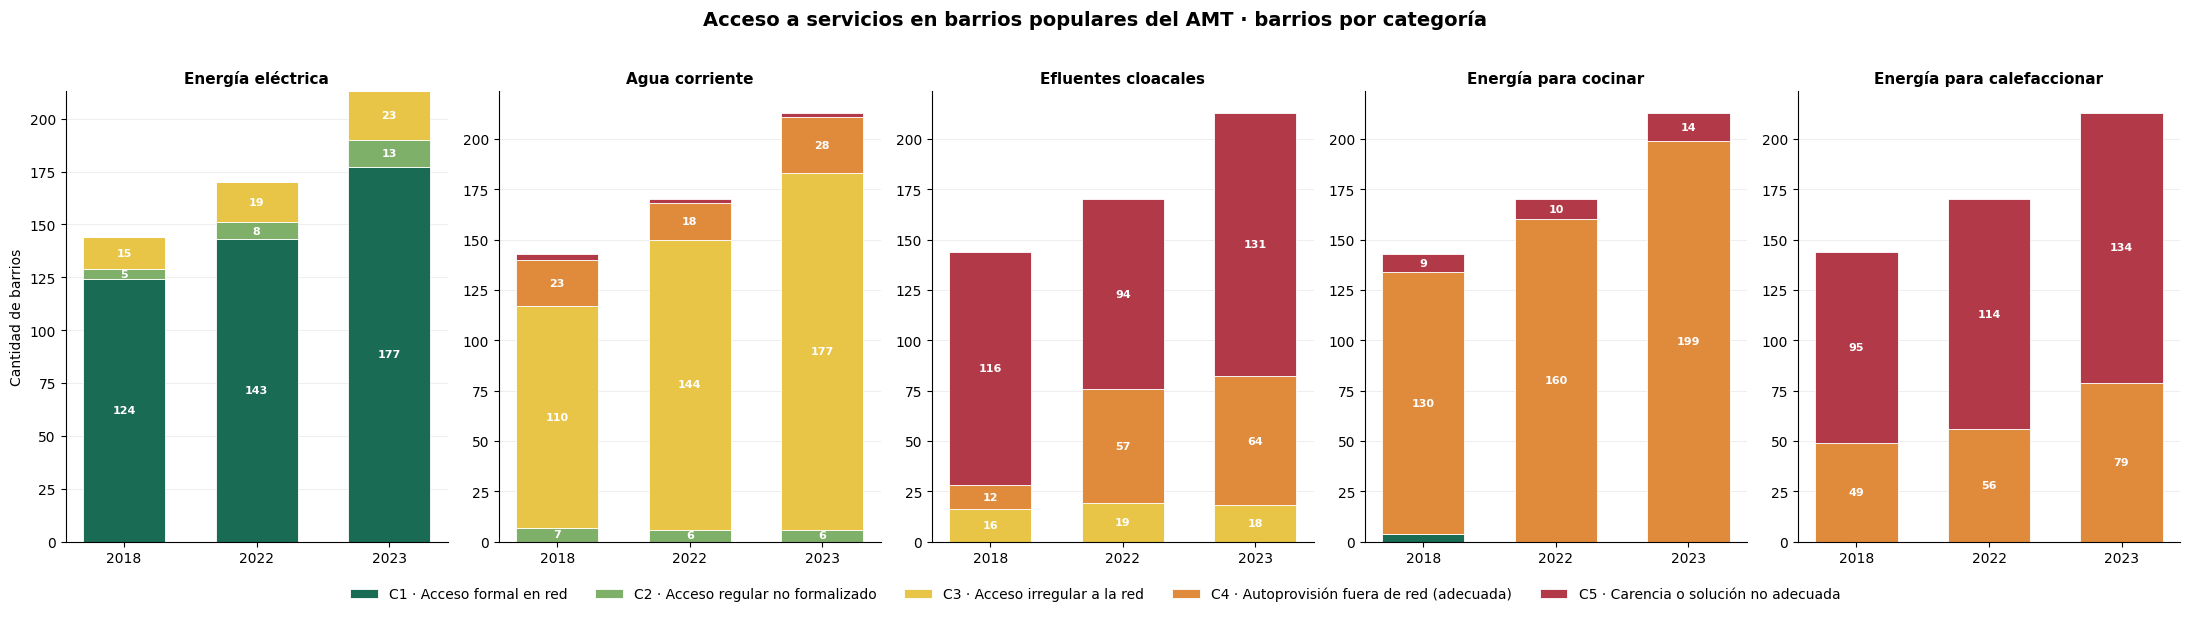

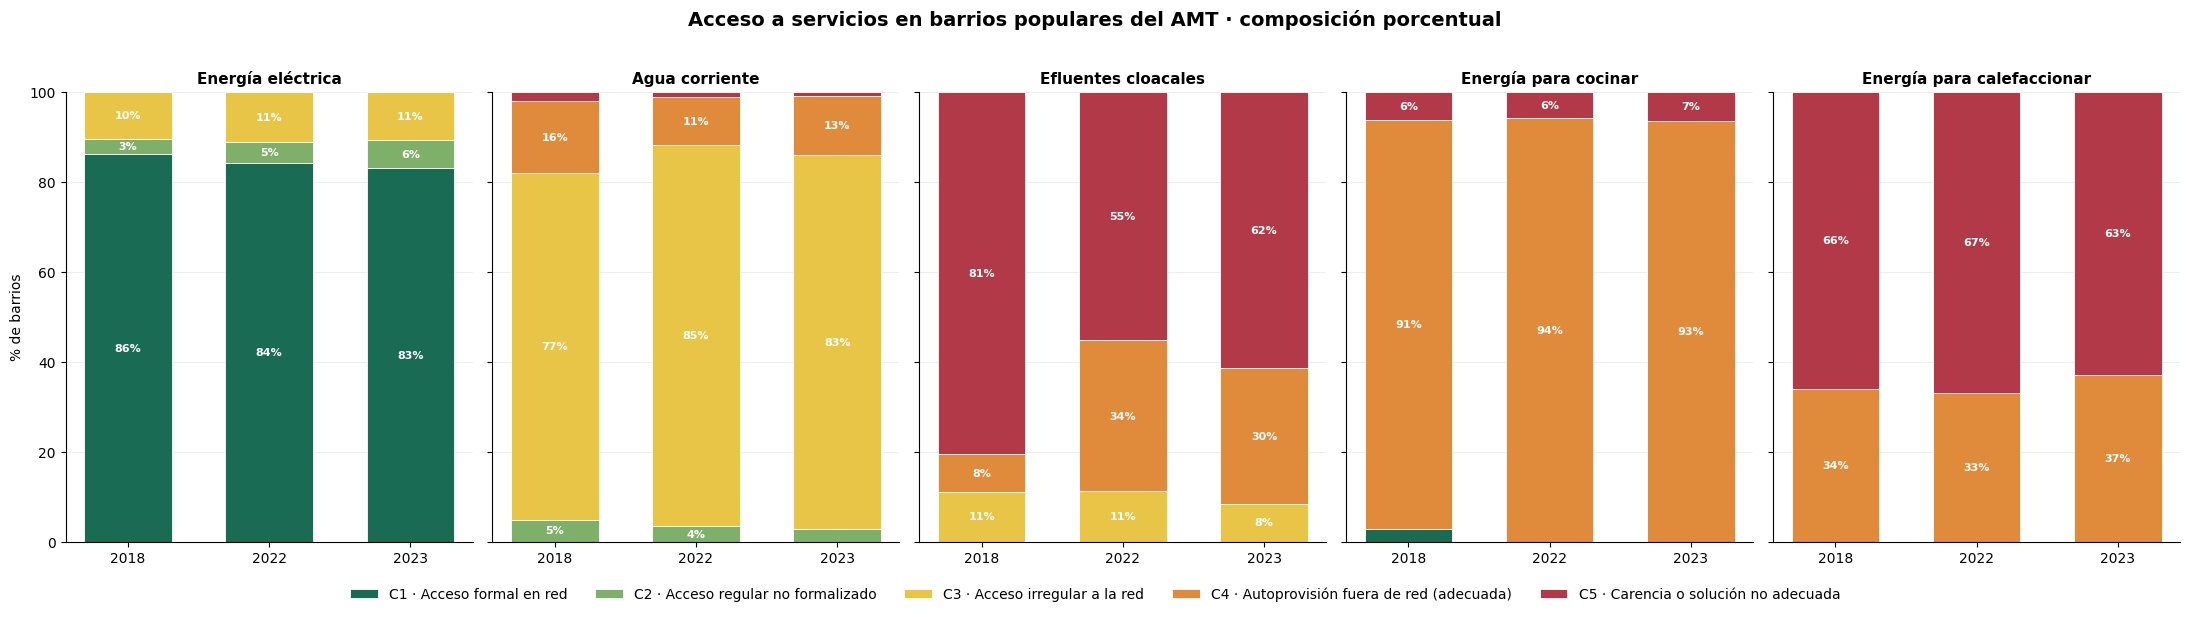

Figuras guardadas en /content/RENABAP/data/processed


In [8]:
# ============================================================
# S7 — Gráficos de distribución por categoría
# ============================================================

def matriz_por_servicio(serv, normalizar=False):
    """Devuelve DataFrame registros × categorías para un servicio."""
    datos = {}
    for a in ANIOS:
        conteo = amt_cat[a][f"{serv}_cat"].value_counts()
        fila = [int(conteo.get(c, 0)) for c in CATEGORIAS]
        if normalizar:
            total = sum(fila)
            fila = [v / total * 100 if total else 0 for v in fila]
        datos[a] = fila
    return pd.DataFrame(datos, index=CATEGORIAS).T


def panel(normalizar, titulo, sufijo_y):
    fig, axes = plt.subplots(1, len(SERVICIOS), figsize=(22, 5.6), sharey=normalizar)
    for ax, serv in zip(axes, SERVICIOS):
        m = matriz_por_servicio(serv, normalizar)
        base = [0] * len(ANIOS)
        x = range(len(ANIOS))
        for cat in CATEGORIAS:
            vals = m[cat].values
            ax.bar(x, vals, bottom=base, color=COLOR_CAT[cat],
                   label=NOMBRE_CAT[cat], width=0.62, edgecolor="white", linewidth=0.6)
            for xi, (v, b) in enumerate(zip(vals, base)):
                if v > (3 if normalizar else 4):
                    ax.text(xi, b + v / 2, f"{v:.0f}" + ("%" if normalizar else ""),
                            ha="center", va="center", fontsize=8,
                            color="white", fontweight="bold")
            base = [b + v for b, v in zip(base, vals)]
        ax.set_xticks(list(x))
        ax.set_xticklabels([str(a) for a in ANIOS])
        ax.set_title(ETIQUETA_SERVICIO[serv], fontsize=11, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linewidth=0.6)
        ax.set_axisbelow(True)
    axes[0].set_ylabel(sufijo_y)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False,
               bbox_to_anchor=(0.5, -0.06), fontsize=10)
    fig.suptitle(titulo, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    return fig


fig1 = panel(False,
             "Acceso a servicios en barrios populares del AMT · barrios por categoría",
             "Cantidad de barrios")
fig1.savefig(DIR_PROC / "servicios_amt_barras_absolutas.png",
             dpi=200, bbox_inches="tight")
plt.show()

fig2 = panel(True,
             "Acceso a servicios en barrios populares del AMT · composición porcentual",
             "% de barrios")
fig2.savefig(DIR_PROC / "servicios_amt_barras_porcentuales.png",
             dpi=200, bbox_inches="tight")
plt.show()

print("Figuras guardadas en", DIR_PROC)

In [9]:
# ============================================================
# S8 — Comparación entre registros (barrios presentes en ambas fotos)
# ============================================================
ESCALERA = {"C1": 4, "C2": 3, "C3": 2, "C4": 1, "C5": 0}
NO_COMPARABLE = {("C3", "C4"), ("C4", "C3")}   # red irregular <-> autoprovisión fuera de red

PARES = [(2018, 2022), (2022, 2023), (2018, 2023)]


def clasificar_cambio(antes, despues):
    if pd.isna(antes) or pd.isna(despues):
        return "sin dato"
    if antes == despues:
        return "sin cambio"
    if (antes, despues) in NO_COMPARABLE:
        return "cambio de modalidad"
    return "asciende" if ESCALERA[despues] > ESCALERA[antes] else "desciende"


def comparar(a0, a1):
    cols = ["id_renabap"] + [f"{s}_cat" for s in SERVICIOS]
    izq = amt_cat[a0][cols].rename(
        columns={f"{s}_cat": f"{s}_{a0}" for s in SERVICIOS})
    der = amt_cat[a1][cols].rename(
        columns={f"{s}_cat": f"{s}_{a1}" for s in SERVICIOS})
    comunes = izq.merge(der, on="id_renabap", how="inner")
    for s in SERVICIOS:
        comunes[f"{s}_cambio"] = [
            clasificar_cambio(x, y)
            for x, y in zip(comunes[f"{s}_{a0}"], comunes[f"{s}_{a1}"])
        ]
    return comunes


ORDEN_CAMBIO = ["asciende", "sin cambio", "desciende", "cambio de modalidad", "sin dato"]
comparaciones, resumenes = {}, []

for a0, a1 in PARES:
    comp = comparar(a0, a1)
    comparaciones[(a0, a1)] = comp

    ids0 = set(amt_cat[a0]["id_renabap"])
    ids1 = set(amt_cat[a1]["id_renabap"])
    print("=" * 78)
    print(f"{a0} -> {a1}   |   en ambas fotos: {len(comp)}   "
          f"|   solo {a0}: {len(ids0 - ids1)}   |   nuevos en {a1}: {len(ids1 - ids0)}")
    print("=" * 78)

    for s in SERVICIOS:
        vc = comp[f"{s}_cambio"].value_counts()
        fila = {"comparacion": f"{a0}->{a1}", "servicio": ETIQUETA_SERVICIO[s],
                "barrios_comparados": len(comp)}
        fila.update({k: int(vc.get(k, 0)) for k in ORDEN_CAMBIO})
        resumenes.append(fila)

    for s in SERVICIOS:
        tabla = pd.crosstab(comp[f"{s}_{a0}"], comp[f"{s}_{a1}"], dropna=False)
        tabla = tabla.reindex(index=CATEGORIAS, columns=CATEGORIAS, fill_value=0)
        if tabla.values.sum() == 0:
            continue
        print(f"\n  {ETIQUETA_SERVICIO[s]} · matriz de transición "
              f"(filas={a0}, columnas={a1})")
        print(tabla.to_string())
    print()

resumen_cambios = pd.DataFrame(resumenes)
print("\n" + "=" * 78)
print("RESUMEN DE CAMBIOS POR SERVICIO")
print("=" * 78)
print(resumen_cambios.to_string(index=False))

resumen_cambios.to_csv(DIR_PROC / "servicios_amt_cambios.csv", index=False)
for (a0, a1), comp in comparaciones.items():
    comp.to_csv(DIR_PROC / f"servicios_amt_cambios_{a0}_{a1}.csv", index=False)
print(f"\nGuardado en {DIR_PROC}")

2018 -> 2022   |   en ambas fotos: 144   |   solo 2018: 0   |   nuevos en 2022: 26

  Energía eléctrica · matriz de transición (filas=2018, columnas=2022)
energia_electrica_2022   C1  C2  C3  C4  C5
energia_electrica_2018                     
C1                      124   0   0   0   0
C2                        1   4   0   0   0
C3                        0   0  15   0   0
C4                        0   0   0   0   0
C5                        0   0   0   0   0

  Agua corriente · matriz de transición (filas=2018, columnas=2022)
agua_corriente_2022  C1  C2   C3  C4  C5
agua_corriente_2018                     
C1                    0   0    0   0   0
C2                    0   3    4   0   0
C3                    0   0  109   1   0
C4                    0   0   10  13   0
C5                    0   0    2   0   1

  Efluentes cloacales · matriz de transición (filas=2018, columnas=2022)
efluentes_cloacales_2022  C1  C2  C3  C4  C5
efluentes_cloacales_2018                    
C1               

In [10]:
# ============================================================
# S9 — Exportación de los tres CSV georreferenciados
# ============================================================
COLS_CONTEXTO = ["nombre_barrio", "localidad", "provincia", "cant_familias",
                 "superficie_ha"]

GPKG_SALIDA = DIR_PROC / "renabap_amt_servicios.gpkg"
if GPKG_SALIDA.exists():
    GPKG_SALIDA.unlink()

rutas = []
primera = True
for a in ANIOS:
    g = amt_cat[a].copy()

    columnas = ["id_renabap", "registro"]
    columnas += [c for c in COLS_CONTEXTO if c in g.columns]
    for serv in SERVICIOS:
        columnas += [serv, f"{serv}_cat", f"{serv}_cat_nombre"]

    salida = g[columnas].copy()

    # geometría: WKT en 4326 + centroide (calculado en CRS métrico para evitar el aviso)
    salida["WKT"] = g.geometry.to_wkt()
    centroides = g.to_crs(CRS_METRICO).geometry.centroid.to_crs(CRS_DATOS)
    salida["lon"] = centroides.x.round(6)
    salida["lat"] = centroides.y.round(6)

    ruta_csv = DIR_PROC / f"RENABAP_AMT_servicios_{a}.csv"
    salida.to_csv(ruta_csv, index=False, encoding="utf-8-sig")
    rutas.append(ruta_csv)

    g_gpkg = g[columnas + ["geometry"]]
    g_gpkg.to_file(GPKG_SALIDA, layer=f"servicios_amt_{a}", driver="GPKG",
                   mode="w" if primera else "a")
    primera = False

    print(f"  {a}: {len(salida):>4} barrios | {len(salida.columns)} columnas -> {ruta_csv.name}")

print(f"\nGPKG con las tres capas: {GPKG_SALIDA.name}")
print(f"Directorio de salida: {DIR_PROC.resolve()}")

# descarga directa desde Colab
if EN_COLAB:
    from google.colab import files
    for r in rutas:
        files.download(str(r))
    files.download(str(GPKG_SALIDA))

  2018:  144 barrios | 25 columnas -> RENABAP_AMT_servicios_2018.csv
  2022:  170 barrios | 25 columnas -> RENABAP_AMT_servicios_2022.csv
  2023:  213 barrios | 25 columnas -> RENABAP_AMT_servicios_2023.csv

GPKG con las tres capas: renabap_amt_servicios.gpkg
Directorio de salida: /content/RENABAP/data/processed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>